#### Sudan Climate Data Analysis

##### Importing libraries


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

Loading data, adding country, creating date and month columns

In [2]:
df = pd.read_csv("../data/Sudan.csv")
df["Country"] = "Sudan"
df["Date"] = pd.to_datetime(df["YEAR"] * 1000 + df["DOY"], format="%Y%j")
df["Month"] = df["Date"].dt.month


df.head()

,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,Country,Date,Month
0,2015,1,25.18,35.55,16.14,19.41,0.0,31.87,3.46,5.12,96.54,6.08,Sudan,2015-01-01,1
1,2015,2,23.92,34.14,15.81,18.33,0.0,23.83,4.24,5.10,96.67,4.31,Sudan,2015-01-02,1
2,2015,3,22.73,31.64,15.09,16.55,0.0,38.21,5.01,6.24,96.77,6.42,Sudan,2015-01-03,1
3,2015,4,19.15,27.35,12.88,14.47,0.0,21.07,5.72,6.96,96.93,3.06,Sudan,2015-01-04,1
4,2015,5,17.54,27.22,9.49,17.73,0.0,21.58,4.28,5.82,96.85,2.86,Sudan,2015-01-05,1


Handling missing values and duplicates

In [3]:
df.replace(-999, np.nan, inplace=True)

duplicates = df.duplicated().sum()
print(f"Found {duplicates} duplicate rows")

if duplicates > 0:
    df = df.drop_duplicates()
    print("Duplicates removed")
else:
    print("No duplicates to remove")


print("\nChecking for missing values...")
missing_count = df.isna().sum()
missing_percent = (missing_count / len(df)) * 100


has_missing = missing_count[missing_count > 0]
if len(has_missing) > 0:
    print("\nColumns with missing values:")
    for col in has_missing.index:
        print(f"  {col}: {has_missing[col]} missing ({missing_percent[col]:.1f}%)")
else:
    print("No missing values found in any column")


high_missing = missing_percent[missing_percent > 5]
if len(high_missing) > 0:
    print("\nColumns with more than 5% missing:")
    for col in high_missing.index:
        print(f"  {col}: {high_missing[col]:.1f}%")
else:
    print("\nNo columns have more than 5% missing values")


print("\nSummary statistics:")
df.describe()

Found 0 duplicate rows
No duplicates to remove

Checking for missing values...
No missing values found in any column

No columns have more than 5% missing values

Summary statistics:


,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,Date,Month
count,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108,4108.000000
mean,2020.131451,180.121227,28.759007,36.773914,21.508510,15.265404,0.643875,31.359192,3.484253,5.157378,96.346273,7.864557,2020-08-15 12:00:00,6.423564
min,2015.000000,1.000000,13.180000,21.040000,5.930000,3.420000,0.000000,4.690000,0.610000,1.030000,95.660000,1.160000,2015-01-01 00:00:00,1.000000
25%,2017.000000,86.000000,25.560000,33.730000,17.497500,13.280000,0.000000,17.407500,2.730000,4.267500,96.160000,3.730000,2017-10-23 18:00:00,3.000000
50%,2020.000000,179.000000,29.160000,37.020000,22.890000,15.810000,0.000000,26.630000,3.490000,5.120000,96.310000,5.895000,2020-08-15 12:00:00,6.000000
75%,2023.000000,272.000000,32.510000,40.330000,25.430000,17.680000,0.010000,40.535000,4.220000,6.020000,96.510000,12.500000,2023-06-08 06:00:00,9.000000
max,2026.000000,366.000000,37.990000,45.960000,32.170000,22.480000,66.490000,87.160000,7.150000,9.050000,97.310000,19.440000,2026-03-31 00:00:00,12.000000
std,3.248907,106.294767,4.681305,4.400065,5.091142,3.298919,3.057672,17.851849,1.040667,1.280238,0.266927,4.880934,NaN,3.477046


The average temperature in Sudan is 28.8°C. Temperatures range from 13.2°C to 38.0°C. Average daily rainfall is 0.6 mm. The heaviest rain day had 66.5 mm. Average humidity is 31.4%. The data covers January 2015 to March 2026.

##### Checking for outliers using Z-scores(Z-score above 3 means the value is far from average)

In [4]:
# Columns to check
outlier_cols = ['T2M', 'T2M_MAX', 'T2M_MIN', 'PRECTOTCORR', 'RH2M', 'WS2M', 'WS2M_MAX']

# Calculate Z-scores
z_scores = np.abs(stats.zscore(df[outlier_cols]))

# Count outliers per column
outlier_count = (z_scores > 3).sum(axis=0)

print("Outliers found per column:")
for col, count in zip(outlier_cols, outlier_count):
    print(f"  {col}: {count} outliers")

# Total outliers
total_outliers = outlier_count.sum()
print(f"\nTotal outliers across all columns: {total_outliers}")

# Export cleaned data
df.to_csv("../data/Sudan_clean.csv", index=False)
print("\nCleaned data saved to data/Sudan_clean.csv")

Outliers found per column:
  T2M: 3 outliers
  T2M_MAX: 6 outliers
  T2M_MIN: 1 outliers
  PRECTOTCORR: 71 outliers
  RH2M: 3 outliers
  WS2M: 4 outliers
  WS2M_MAX: 3 outliers

Total outliers across all columns: 91

Cleaned data saved to data/Sudan_clean.csv


I found 91 outliers. Most of them are in rainfall (71 outliers).Rainfall has many outliers because some days get heavy rain while most days have little or no rain. That's normal for Sudan.I decided to keep all outliers. Extreme weather really happens. Removing them would make the data less realistic.

##### Plotting monthly average temperature (T2M) line chart

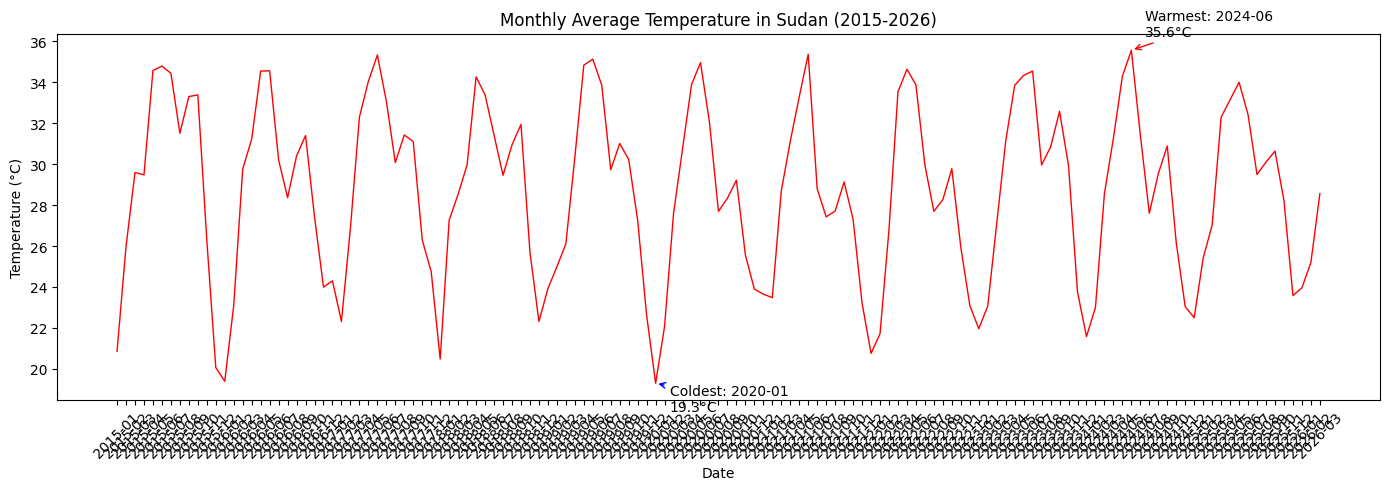

In [5]:
monthly_temp = df.groupby(df['Date'].dt.to_period('M'))['T2M'].mean()

plt.figure(figsize=(14, 5))
plt.plot(monthly_temp.index.astype(str), monthly_temp.values, color='red', linewidth=1)

# Find warmest and coldest months
warmest = monthly_temp.idxmax()
coldest = monthly_temp.idxmin()
warmest_val = monthly_temp.max()
coldest_val = monthly_temp.min()

plt.annotate(f'Warmest: {warmest}\n{warmest_val:.1f}°C', 
             xy=(list(monthly_temp.index).index(warmest), warmest_val),
             xytext=(10, 10), textcoords='offset points',
             arrowprops=dict(arrowstyle='->', color='red'))

plt.annotate(f'Coldest: {coldest}\n{coldest_val:.1f}°C',
             xy=(list(monthly_temp.index).index(coldest), coldest_val),
             xytext=(10, -20), textcoords='offset points',
             arrowprops=dict(arrowstyle='->', color='blue'))

plt.title('Monthly Average Temperature in Sudan (2015-2026)')
plt.xlabel('Date')
plt.ylabel('Temperature (°C)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

##### Plotting monthly total rainfall(PRECTOTCORR) bar chart

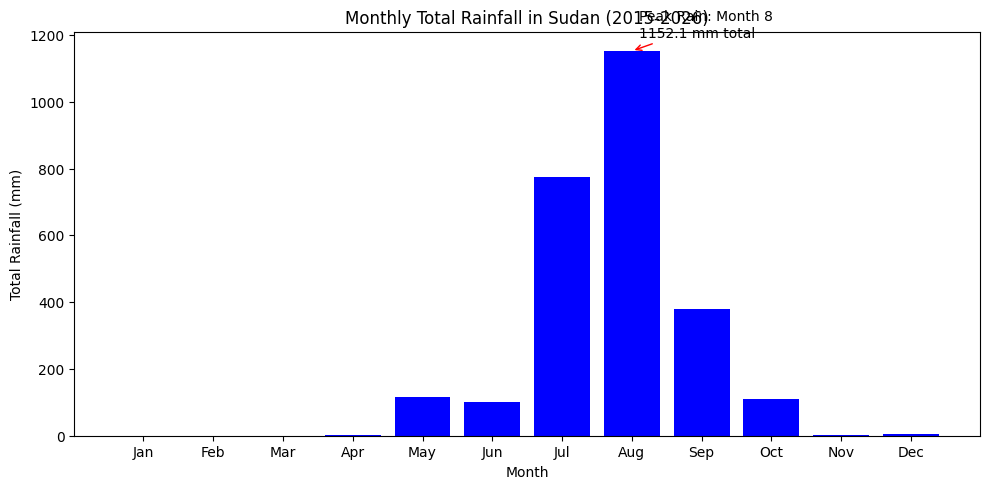

In [6]:
monthly_rain = df.groupby('Month')['PRECTOTCORR'].sum()

plt.figure(figsize=(10, 5))
plt.bar(monthly_rain.index, monthly_rain.values, color='blue')

# Find peak rainy month
peak_month = monthly_rain.idxmax()
peak_val = monthly_rain.max()

plt.annotate(f'Peak Rain: Month {peak_month}\n{peak_val:.1f} mm total',
             xy=(peak_month, peak_val),
             xytext=(5, 10), textcoords='offset points',
             arrowprops=dict(arrowstyle='->', color='red'))

plt.title('Monthly Total Rainfall in Sudan (2015-2026)')
plt.xlabel('Month')
plt.ylabel('Total Rainfall (mm)')
plt.xticks(range(1, 13), ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec'])
plt.tight_layout()
plt.show()

The warmest month was June 2024 at 35.6°C. The coldest month was January 2020 at 19.3°C.
August has the most rain with 1152.1 mm total. Rainfall is highest in August. The driest months appear to be January.
Temperatures go up and down each year but don't get much hotter or colder over time.

##### Creating correlation heatmap to see how weather variables relate to each other.

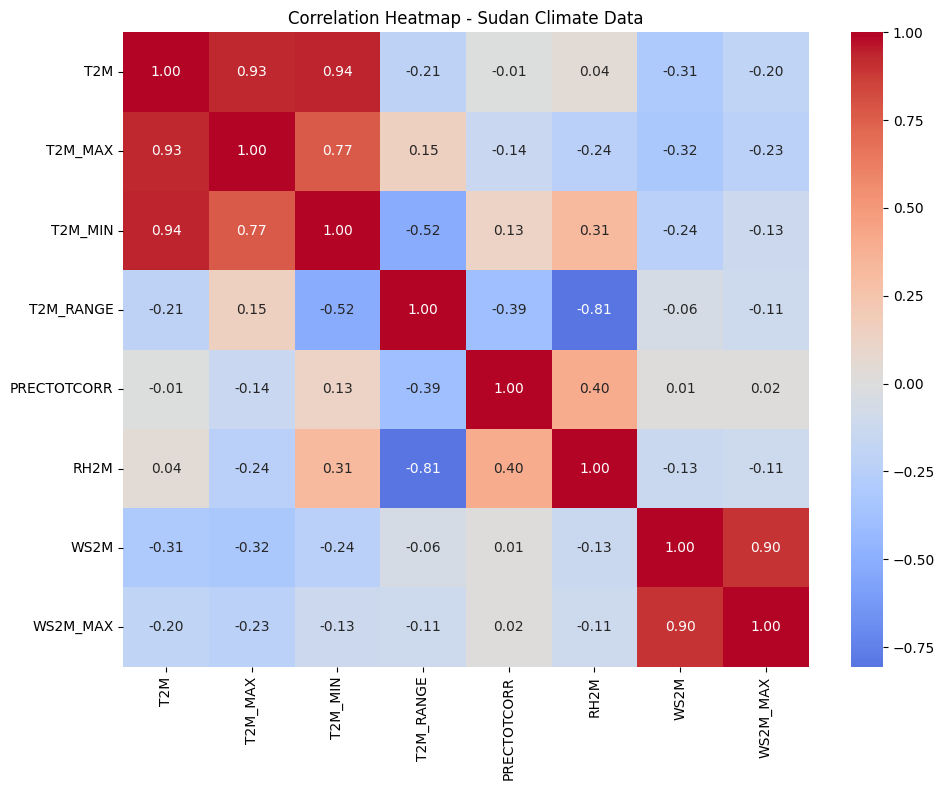

In [7]:
numeric_cols = ['T2M', 'T2M_MAX', 'T2M_MIN', 'T2M_RANGE', 'PRECTOTCORR', 'RH2M', 'WS2M', 'WS2M_MAX']

corr = df[numeric_cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, cmap='coolwarm', center=0, fmt='.2f')
plt.title('Correlation Heatmap - Sudan Climate Data')
plt.tight_layout()
plt.show()

##### Scatter plot: Temperature vs Humidity

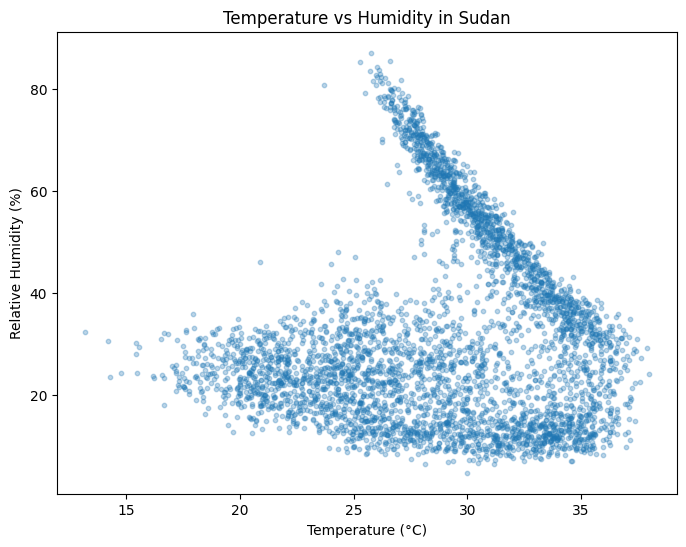

In [8]:
plt.figure(figsize=(8, 6))
plt.scatter(df['T2M'], df['RH2M'], alpha=0.3, s=10)
plt.xlabel('Temperature (°C)')
plt.ylabel('Relative Humidity (%)')
plt.title('Temperature vs Humidity in Sudan')
plt.show()

##### Scatter plot: Temperature Range vs Wind Speed

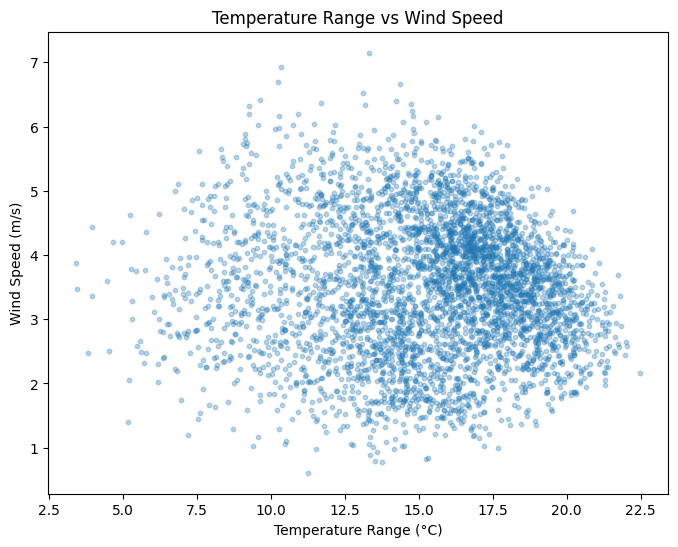

In [9]:
plt.figure(figsize=(8, 6))
plt.scatter(df['T2M_RANGE'], df['WS2M'], alpha=0.3, s=10)
plt.xlabel('Temperature Range (°C)')
plt.ylabel('Wind Speed (m/s)')
plt.title('Temperature Range vs Wind Speed')
plt.show()

The three strongest correlations I see are:

1. Temperature columns are all strongly correlated (0.93 to 0.94). When it's hot, everything is hot.
2. Humidity and minimum temperature have a negative relationship (-0.52). Cooler nights have higher humidity.
3. Wind speed columns are correlated (0.90).

##### Histogram of rainfall

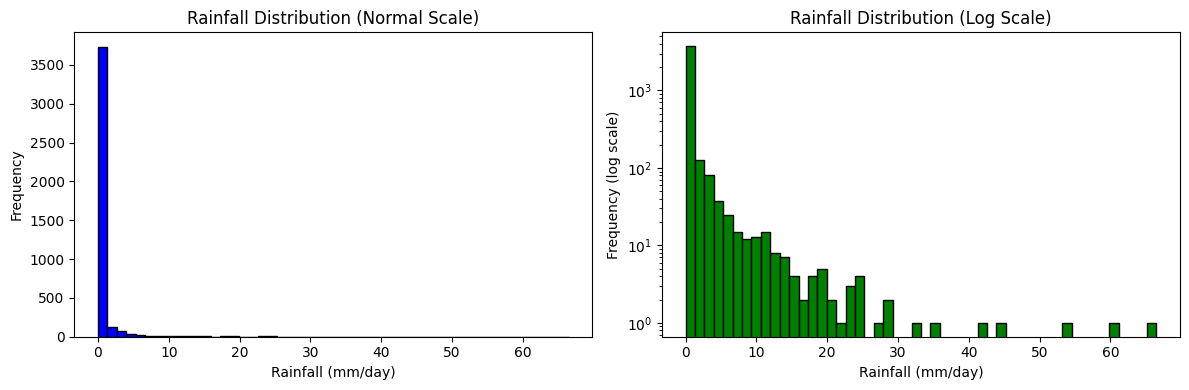

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(df['PRECTOTCORR'], bins=50, color='blue', edgecolor='black')
axes[0].set_title('Rainfall Distribution (Normal Scale)')
axes[0].set_xlabel('Rainfall (mm/day)')
axes[0].set_ylabel('Frequency')


axes[1].hist(df['PRECTOTCORR'], bins=50, color='green', edgecolor='black', log=True)
axes[1].set_title('Rainfall Distribution (Log Scale)')
axes[1].set_xlabel('Rainfall (mm/day)')
axes[1].set_ylabel('Frequency (log scale)')

plt.tight_layout()
plt.show()

Most days have little or no rain. A few days have a lot of rain up to 60 mm. This is called a skewed distribution. 

##### Bubble chart: Temperature vs Humidity, bubble size = Rainfall

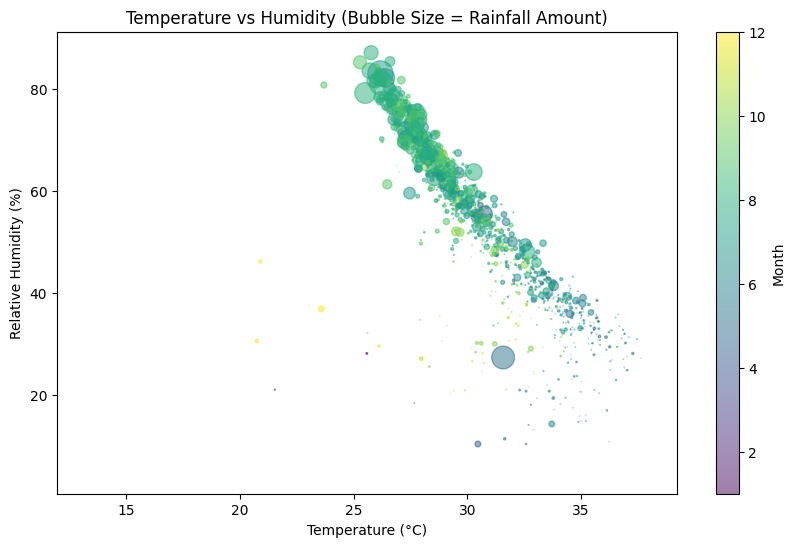

In [11]:

plt.figure(figsize=(10, 6))
scatter = plt.scatter(df['T2M'], df['RH2M'], 
                      s=df['PRECTOTCORR'] * 5,  # bubble size = rainfall
                      alpha=0.5, c=df['Month'], cmap='viridis')
plt.colorbar(label='Month')
plt.xlabel('Temperature (°C)')
plt.ylabel('Relative Humidity (%)')
plt.title('Temperature vs Humidity (Bubble Size = Rainfall Amount)')
plt.show()

Bigger bubbles (more rain) happen when temperature is cooler. Smaller bubbles (less rain) happen when it's hotter.